# Polynomial Regression using Raw Tensors

In this tutorial, we will use **Nanograd** to fit a 3rd-degree polynomial:
$$y = a x^3 + b x^2 + c x + d$$
to a noisy sine wave. We will do this by manipulating raw **Tensors** and writing a custom training loop with manual gradient descent updates, showing the inner workings of autograd without high-level neural network layers.

---

In [11]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from nanograd import Tensor

np.random.seed(42)

## 1. Generating Noisy Target Data

We will generate target points using the sine function in the range $[-2, 2]$ and add Gaussian noise.

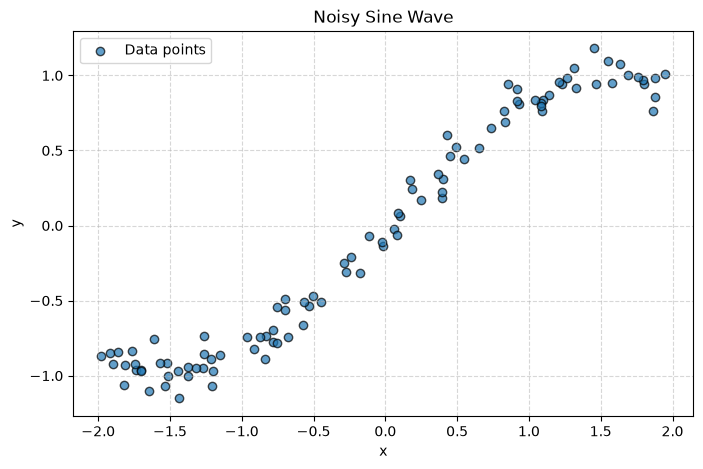

In [12]:
# Generate 100 random points
x_np = np.random.uniform(-2.0, 2.0, size=(100, 1))
# Target: y = sin(x) + noise
y_np = np.sin(x_np) + np.random.normal(0, 0.1, size=x_np.shape)

# Wrap inputs and targets in Tensors
x = Tensor(x_np, label='x')
y_true = Tensor(y_np, label='y_true')

# Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(x_np, y_np, color='#1f77b4', alpha=0.7, label='Data points', edgecolors='k')
plt.title('Noisy Sine Wave')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 2. Initializing Polynomial Coefficients

We will declare four parameter tensors $a, b, c, d$ representing the coefficients of our polynomial $y = a x^3 + b x^2 + c x + d$. We initialize them randomly.

In [13]:
a = Tensor(np.random.randn(1, 1), label='a')
b = Tensor(np.random.randn(1, 1), label='b')
c = Tensor(np.random.randn(1, 1), label='c')
d = Tensor(np.random.randn(1, 1), label='d')

print(f"Initial: a={a.data.item():.4f}, b={b.data.item():.4f}, c={c.data.item():.4f}, d={d.data.item():.4f}")

Initial: a=0.0130, b=1.4535, c=-0.2647, d=2.7202


## 3. Training Loop (Manual Gradient Descent)

We will run 80 epochs of training. In each epoch we:
1. Calculate predictions: `y_pred = a * x**3 + b * x**2 + c * x + d`
2. Calculate Mean Squared Error (MSE) loss: `loss = ((y_pred - y_true)**2).sum() / n`
3. Run `loss.backward()` to compute partial derivatives.
4. Manually update coefficients using standard gradient descent updates ($W = W - \eta \cdot \frac{\partial L}{\partial W}$).
5. Zero out the gradients of the parameters before the next iteration.

In [14]:
lr = 0.02
epochs = 400
loss_history = []
n = x_np.shape[0]

print("Starting optimization...")
for epoch in range(epochs):
    # 1. Forward pass
    x3 = x ** 3
    x2 = x ** 2
    y_pred = a * x3 + b * x2 + c * x + d
    
    # 2. MSE Loss
    diff = y_pred - y_true
    loss = (diff ** 2).sum() / n
    loss_history.append(loss.data.item())
    
    # 3. Backward pass
    loss.backward()
    
    # 4. Manual update step
    a.data -= lr * a.grad
    b.data -= lr * b.grad
    c.data -= lr * c.grad
    d.data -= lr * d.grad
    
    # 5. Reset gradients to zero
    a.grad = np.zeros(a.shape())
    b.grad = np.zeros(b.shape())
    c.grad = np.zeros(c.shape())
    d.grad = np.zeros(d.shape())
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} | MSE Loss: {loss.data.item():.6f}")

Starting optimization...
Epoch  1/400 | MSE Loss: 28.177626
Epoch 10/400 | MSE Loss: 2.264034
Epoch 20/400 | MSE Loss: 0.982236
Epoch 30/400 | MSE Loss: 0.739947
Epoch 40/400 | MSE Loss: 0.577893
Epoch 50/400 | MSE Loss: 0.453691
Epoch 60/400 | MSE Loss: 0.357701
Epoch 70/400 | MSE Loss: 0.283318
Epoch 80/400 | MSE Loss: 0.225529
Epoch 90/400 | MSE Loss: 0.180507
Epoch 100/400 | MSE Loss: 0.145328
Epoch 110/400 | MSE Loss: 0.117751
Epoch 120/400 | MSE Loss: 0.096061
Epoch 130/400 | MSE Loss: 0.078940
Epoch 140/400 | MSE Loss: 0.065376
Epoch 150/400 | MSE Loss: 0.054588
Epoch 160/400 | MSE Loss: 0.045974
Epoch 170/400 | MSE Loss: 0.039067
Epoch 180/400 | MSE Loss: 0.033507
Epoch 190/400 | MSE Loss: 0.029013
Epoch 200/400 | MSE Loss: 0.025364
Epoch 210/400 | MSE Loss: 0.022391
Epoch 220/400 | MSE Loss: 0.019958
Epoch 230/400 | MSE Loss: 0.017959
Epoch 240/400 | MSE Loss: 0.016310
Epoch 250/400 | MSE Loss: 0.014946
Epoch 260/400 | MSE Loss: 0.013813
Epoch 270/400 | MSE Loss: 0.012870
Epoc

## 4. Visualizing the Polynomial Fit

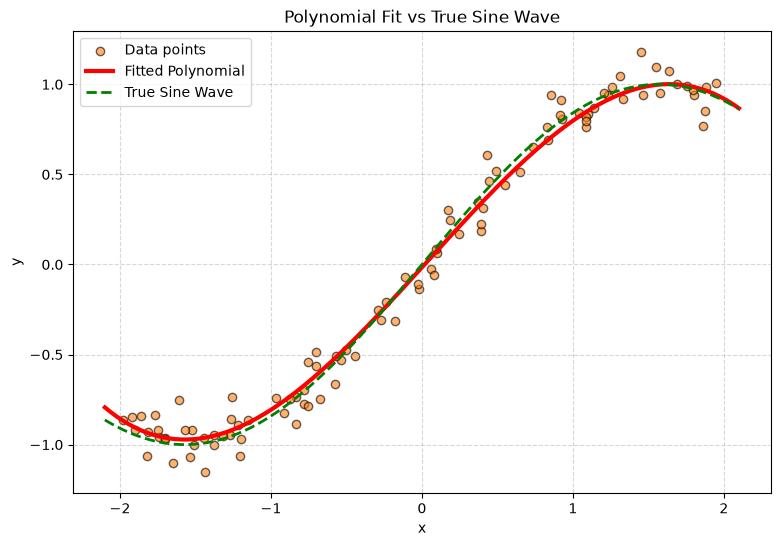

In [15]:
# Generate grid points for smooth plotting
grid_x = np.linspace(-2.1, 2.1, 200).reshape(-1, 1)

# Calculate fitted polynomial
y_fitted = a.data * (grid_x ** 3) + b.data * (grid_x ** 2) + c.data * grid_x + d.data

# Calculate true underlying sine wave
y_sine = np.sin(grid_x)

# Plot everything
plt.figure(figsize=(9, 6))
plt.scatter(x_np, y_np, color='#ff7f0e', alpha=0.6, label='Data points', edgecolors='k')
plt.plot(grid_x, y_fitted, color='red', linewidth=3, label='Fitted Polynomial')
plt.plot(grid_x, y_sine, color='green', linestyle='--', linewidth=2, label='True Sine Wave')
plt.title('Polynomial Fit vs True Sine Wave')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()